# Exam Score Prediction

## Objective

The goal of this section is to predict a student's final exam score using behavioral and academic features.

Target Variable:
- exam_score

Features:
- study_hours
- attendance
- sleep_hours
- internet_usage
- assignments_completed
- previous_score

Two models will be evaluated:

1. Linear Regression
2. Random Forest Regressor

The models will be compared using:

- R² Score
- Mean Absolute Error (MAE)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)

## Dataset

In [3]:
df = pd.read_csv(
    "../data/student_dataset_10000_rows.csv"
)

df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


## Feature Selection

The target variable for this task is `exam_score`.

All remaining student-related variables are used as predictors.

In [4]:
X = df.drop(
    ["exam_score", "placement_status"],
    axis=1
)

y = df["exam_score"]

## Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

A fixed random state is used to ensure reproducibility.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression

Linear Regression serves as a baseline model.

The model assumes a linear relationship between the input variables and the target variable.

In [6]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

print(f"R²: {lr_r2:.3f}")
print(f"MAE: {lr_mae:.3f}")

R²: 0.663
MAE: 6.917


## Random Forest Regressor

Random Forest is an ensemble learning algorithm capable of capturing nonlinear relationships and interactions between variables.

In [7]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

print(f"R²: {rf_r2:.3f}")
print(f"MAE: {rf_mae:.3f}")

R²: 0.713
MAE: 5.876


In [8]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "R2": [
        lr_r2,
        rf_r2
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ]
})

results

,Model,R2,MAE
0,Linear Regression,0.663446,6.917286
1,Random Forest,0.712875,5.875946


## Feature Importance Analysis

Feature importance values were extracted from the Random Forest model to understand which variables contribute most to exam score prediction.

In [9]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
0,study_hours,0.347723
4,assignments_completed,0.208593
5,previous_score,0.178134
1,attendance,0.134933
3,internet_usage,0.074150
2,sleep_hours,0.056468


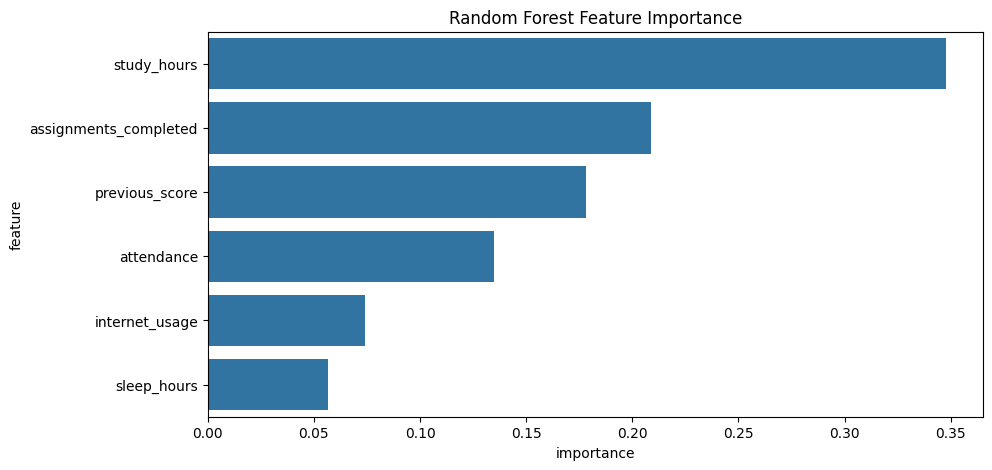

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

# Findings

## Model Performance

Random Forest outperformed Linear Regression.

| Model | R² | MAE |
|---------|---------|---------|
| Linear Regression | 0.663 | 6.917 |
| Random Forest | 0.713 | 5.876 |

The Random Forest model explained approximately 71% of the variance in student exam scores and achieved an average prediction error of 5.9 points.

## Key Drivers of Student Performance

Feature importance analysis revealed:

1. Study Hours (34.8%)
2. Assignments Completed (20.9%)
3. Previous Score (17.8%)
4. Attendance (13.5%)

These findings suggest that academic engagement and consistent study habits are stronger predictors of success than sleep duration or internet usage.

## Business Implications

Educational institutions could use these factors to identify students who may require additional academic support.

Increasing study time and assignment completion rates may have the greatest impact on improving exam outcomes.